<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Midterm%20Project/notebooks/03_Extension_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extension: Testing the Parallel Trends Assumption

This extension strengthens the original Card and Krueger (1994) replication by evaluating the plausibility of the parallel trends assumption using external macroeconomic data.

## Motivation

The validity of the difference-in-differences (DID) estimator relies on the parallel trends assumption, which states that in the absence of treatment, the treatment and control groups would have followed similar trends over time.

This assumption cannot be directly tested using only the original dataset. Therefore, I use external macroeconomic data to assess whether New Jersey (treatment) and Pennsylvania (control) exhibited similar labor market trends prior to the 1992 minimum wage increase.

## Data Enrichment Strategy

This extension follows the Data Enrichment pathway by incorporating external data from the Federal Reserve Economic Data (FRED) database.

Specifically, I use state-level unemployment rates for New Jersey and Pennsylvania as a proxy for underlying labor market conditions. If these trends are similar prior to the policy change, it supports the credibility of the DID identification strategy.

In [1]:
!pip install fredapi

In [2]:
from fredapi import Fred
import pandas as pd
import matplotlib.pyplot as plt

fred = Fred(api_key="82078b7e0f65bcf75cbf64afe01471d7")

In [3]:
# Pull unemployment data
nj_ur = fred.get_series("NJUR")
pa_ur = fred.get_series("PAUR")

# Create dataframe
unemp = pd.DataFrame({
    "NJ_unemp": nj_ur,
    "PA_unemp": pa_ur
})

# Convert index to datetime
unemp.index = pd.to_datetime(unemp.index)

# Filter to pre-treatment period
unemp = unemp.loc["1990-01-01":"1992-12-31"].copy()

print(unemp.head())
print(unemp.shape)

            NJ_unemp  PA_unemp
1990-01-01       4.5       5.2
1990-02-01       4.6       5.2
1990-03-01       4.6       5.2
1990-04-01       4.7       5.2
1990-05-01       4.7       5.2
(36, 2)


## Visualization of Pre-Treatment Trends

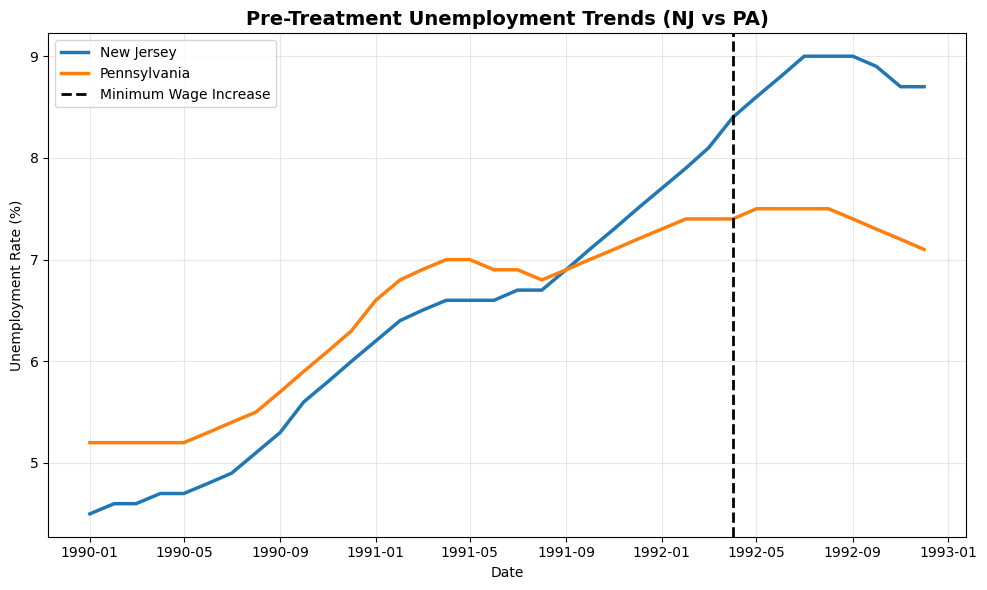

In [4]:
plt.figure(figsize=(10,6))

plt.plot(unemp.index, unemp["NJ_unemp"], linewidth=2.5, label="New Jersey")
plt.plot(unemp.index, unemp["PA_unemp"], linewidth=2.5, label="Pennsylvania")

plt.axvline(pd.to_datetime("1992-04-01"), linestyle="--", linewidth=2, color="black", label="Minimum Wage Increase")

plt.title("Pre-Treatment Unemployment Trends (NJ vs PA)", fontsize=14, weight='bold')
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## GenAI Transparency Statement

I used ChatGPT to assist with:
- debugging Python and pandas code,
- generating FRED data retrieval scripts,
- and improving the clarity of visualizations and written explanations.

## Interpretation

To evaluate the plausibility of the parallel trends assumption, I compare unemployment trends in New Jersey and Pennsylvania prior to the April 1992 minimum wage increase.

The two states exhibit broadly similar movements in unemployment before the policy change. The similarity in pre-treatment trends suggests that New Jersey and Pennsylvania were on comparable labor market trajectories prior to the policy change, reinforcing the credibility of the DID identification strategy.

## Executive Summary

This project replicates the main findings of Card and Krueger (1994) using a difference-in-differences framework comparing fast-food restaurants in New Jersey and Pennsylvania before and after the 1992 minimum wage increase. After constructing full-time equivalent (FTE) employment measures and estimating the DID model with clustered standard errors, the results indicate a positive treatment effect, suggesting that employment in New Jersey did not decline relative to Pennsylvania following the policy change. This finding is consistent with the original paper’s conclusion.

As an extension, I incorporate external macroeconomic data from FRED to assess the validity of the parallel trends assumption. The pre-treatment unemployment trends in New Jersey and Pennsylvania appear broadly similar, supporting the credibility of the DID identification strategy. This extension strengthens the original findings by demonstrating that the identifying assumption underlying the DID framework is supported by independent macroeconomic evidence.